# Генеративные классификаторы — собственные данные

Работа состоит из двух частей:

- **Часть 1. Multinomial Naïve Bayes** — классификация email-спама (Spam or Not Spam Dataset, 1000 сообщений, сбалансированные классы).
- **Части 2–4. QDA / LDA / Gaussian NB** — классификация качества красного вина (Red Wine Quality, те же данные, что в работах по GLM и SVM).

Датасет: Spam or Not Spam                                                                                                                          
                                                                                                                                                     
  Датасет содержит 1000 email-сообщений с бинарными метками:      
  - 1 (spam) — нежелательное письмо                                                                                                                  
  - 0 (ham) — обычное, легитимное письмо                                                                                                             
                                                                                                                                                     
  Классы сбалансированы: по 500 сообщений каждого типа.                                                                                              
                                                                                                                                                     
  Источник: https://www.kaggle.com/datasets/ozlerhakan/spam-or-not-spam-dataset                                                                      
  Оригинальные письма взяты из публичного корпуса https://spamassassin.apache.org/old/publiccorpus/.                                                 
                                                                                                                                                     
  Предобработка, выполненная до загрузки:                                                                                                            
  - все числовые значения заменены на токен NUMBER                                                                                                   
  - все URL-ссылки заменены на токен URL                                                                                                             
                                                                  
  Это позволяет модели опираться на паттерн присутствия чисел и ссылок в тексте, а не на их конкретные значения.                                     
                                                                                                                                                     
  Структура файла: CSV с разделителем ;, два столбца — email (текст письма) и label (метка класса).  

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import re
from sklearn.datasets import load_iris

---
## Часть 1. Multinomial Naïve Bayes

### Загрузка данных

Датасет **Spam or Not Spam** — 1000 email-сообщений (500 спам, 500 не-спам (ham). Числа заменены на `NUMBER`, ссылки на `URL`.

In [2]:
file_id = '1wgnta3lwJ1aJYfRquz34vJSxpIxlcbxL'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'
spam_raw = pd.read_csv(file_url, sep=';')

print('Форма датасета:', spam_raw.shape)
print('Столбцы:', spam_raw.columns.tolist())
print('\nРаспределение классов:')
print(spam_raw['label'].value_counts())
spam_raw.head(3)

Форма датасета: (1000, 2)
Столбцы: ['email', 'label']

Распределение классов:
label
0    500
1    500
Name: count, dtype: int64


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0


Переименуем столбцы в соответствии с интерфейсом класса `MultinomialNaiveBayes` из лекции и разобьём на обучающую и тестовую выборки.

In [3]:
spam_df = spam_raw.rename(columns={'email': 'text', 'label': 'is_spam'})
spam_df['is_spam'] = spam_df['is_spam'].astype(bool)
spam_df = spam_df.dropna(subset=['text']).reset_index(drop=True)
print(f'После удаления пустых строк: {spam_df.shape}')

train_spam, test_spam = train_test_split(
    spam_df, test_size=0.2, random_state=42, stratify=spam_df['is_spam']
)
train_spam = train_spam.reset_index(drop=True)
test_spam  = test_spam.reset_index(drop=True)

print(f'Обучающая: {train_spam.shape}, тестовая: {test_spam.shape}')
print('Спам в тесте:', test_spam['is_spam'].sum(),
      '/ Ham:', (~test_spam['is_spam']).sum())

После удаления пустых строк: (999, 2)
Обучающая: (799, 2), тестовая: (200, 2)
Спам в тесте: 100 / Ham: 100


### Класс MultinomialNaiveBayes

In [4]:
class MultinomialNaiveBayes:
  def __init__(self, alpha = 1):
    self.alpha = alpha
    self.token_spam_counts = defaultdict(int)
    self.token_ham_counts = defaultdict(int)
    self.spam_messages = self.ham_messages = 0

  def tokenize(self, text):
    text = text.lower()
    all_words = re.findall("[a-z']+", text)
    return all_words

  def fit(self, data):
    for message in data.itertuples():
      if message.is_spam:
        self.spam_messages += 1
      else:
        self.ham_messages += 1

      for token in self.tokenize(message.text):
        if message.is_spam:
          self.token_spam_counts[token] += 1
        else:
          self.token_ham_counts[token] += 1

  def _likelihood(self, token):
    spam = self.token_spam_counts[token]
    ham = self.token_ham_counts[token]

    total_spam_words = sum(self.token_spam_counts.values())
    total_ham_words = sum(self.token_ham_counts.values())

    unique_spam_words = len(self.token_spam_counts)
    unique_ham_words = len(self.token_ham_counts)

    p_token_spam = (spam + self.alpha) / (total_spam_words + self.alpha * unique_spam_words)
    p_token_ham  = (ham  + self.alpha) / (total_ham_words  + self.alpha * unique_ham_words)

    return p_token_spam, p_token_ham

  def predict(self, data):
    log_spam_prior = np.log(self.spam_messages / len(data))
    log_ham_prior  = np.log(self.ham_messages  / len(data))

    data['predictions'] = False

    for message in data.itertuples():
      text_tokens = self.tokenize(message.text)
      log_prob_if_spam = log_prob_if_ham = 0.0

      for token in text_tokens:
        prob_if_spam, prob_if_ham = self._likelihood(token)
        log_prob_if_spam += np.log(prob_if_spam)
        log_prob_if_ham  += np.log(prob_if_ham)

      log_prob_if_spam = log_spam_prior + log_prob_if_spam
      log_prob_if_ham  = log_ham_prior  + log_prob_if_ham

      data.loc[message.Index, 'predictions'] = log_prob_if_spam > log_prob_if_ham

    return data

### Обучение и оценка качества

In [5]:
mnb = MultinomialNaiveBayes()
mnb.fit(train_spam)
test_spam = mnb.predict(test_spam)

print('Точность на тесте:', accuracy_score(test_spam.is_spam, test_spam.predictions))

Точность на тесте: 0.975


Модель обучается на обучающей выборке: подсчитываются частоты каждого слова отдельно для спам- и ham-сообщений, вычисляется априорная вероятность
  каждого класса. Затем для каждого сообщения из тестовой выборки модель вычисляет логарифм апостериорной вероятности для обоих классов и присваивает
   метку того класса, у которого вероятность выше.

  Точность 0.975 означает, что модель правильно классифицировала 195 из 200 тестовых сообщений. Это высокий результат, характерный для задачи
  классификации спама: несмотря на допущение о независимости слов, Multinomial NB хорошо улавливает характерную лексику спама (например,
  слова типа money, free, click, а также высокую частоту токенов URL и NUMBER).

### Генеративная модель

Как и любой генеративный классификатор, Multinomial NB моделирует распределение данных внутри каждого класса — и может генерировать новые примеры.

Возьмём **топ-8 наиболее характерных спам-слов** (с наибольшим отношением P(слово|spam) / P(слово|ham)) и сгенерируем несколько синтетических спам-сообщений через `np.random.multinomial`.

In [6]:
# Найдём топ-8 наиболее характерных слов для спама
spam_words = [
    (token, *mnb._likelihood(token))
    for token in mnb.token_spam_counts
    if mnb.token_spam_counts[token] > 5
]
spam_words.sort(key=lambda x: x[1] / x[2], reverse=True)
top_words = spam_words[:8]

print('Топ-8 спам-слов (слово, P(spam), P(ham)):')
for word, ps, ph in top_words:
    print(f'  {word:20s}  spam={ps:.5f}  ham={ph:.5f}')

# Вероятности этих слов для спама (нормализуем)
probs = np.array([ps for _, ps, _ in top_words])
probs = probs / probs.sum()
words = [w for w, _, _ in top_words]

# Генерируем 5 синтетических спам-сообщений из 6 слов
print('\nСинтетические спам-сообщения (каждая строка — количество вхождений каждого слова):')
samples = np.random.multinomial(6, probs, size=5)
for row in samples:
    msg = ' '.join([words[i] for i, cnt in enumerate(row) for _ in range(cnt)])
    print(' ', msg)

Топ-8 спам-слов (слово, P(spam), P(ham)):
  hyperlink             spam=0.00404  ham=0.00003
  enenkio               spam=0.00082  ham=0.00001
  click                 spam=0.00207  ham=0.00003
  mails                 spam=0.00065  ham=0.00001
  grants                spam=0.00065  ham=0.00001
  islands               spam=0.00064  ham=0.00001
  kingdom               spam=0.00063  ham=0.00001
  atoll                 spam=0.00046  ham=0.00001

Синтетические спам-сообщения (каждая строка — количество вхождений каждого слова):
  hyperlink hyperlink hyperlink click mails mails
  hyperlink hyperlink hyperlink click click click
  hyperlink hyperlink hyperlink hyperlink click mails
  hyperlink hyperlink hyperlink hyperlink hyperlink click
  hyperlink hyperlink click click click grants


Из обученной модели извлекаем 8 слов с наибольшим отношением P(слово|spam) / P(слово|ham) — то есть слов, которые встречаются в спаме значительно
  чаще, чем в обычных письмах. Лидер — hyperlink: его вероятность в спаме (примерно 0.004) примерно в 130 раз выше, чем в ham (примерно 0.00003). Остальные слова (click, mails, grants, kingdom и др.) также характерны для типичного спама — призывы к действию, обещания денег и наград.

  Синтетические сообщения генерируются через np.random.multinomial: для каждого из 5 сообщений случайным образом распределяются 6 «слотов» между 8
  словами согласно их нормализованным вероятностям. Поскольку hyperlink доминирует по вероятности, оно встречается почти в каждом сгенерированном
  сообщении. Это наглядно показывает, как генеративная модель «думает» о спаме: она запомнила распределение слов внутри класса и воспроизводит его
  при генерации.

---
## Части 2–4. QDA, LDA, Gaussian Naïve Bayes — данные о качестве вина

Три алгоритма Гауссовского дискриминантного анализа применимы к **количественным признакам**. Используем уже знакомый датасет Red Wine Quality.

### Загрузка и подготовка данных

In [7]:
file_id_wine = '1Sb3HGWMlKob3_-rEgqfudszz0ujhVTV9'
file_url_wine = f'https://drive.google.com/uc?export=download&id={file_id_wine}'
df_wine = pd.read_csv(file_url_wine)
df_wine.columns = [c.replace(' ', '_') for c in df_wine.columns]

print('Форма:', df_wine.shape)
df_wine.head(3)

Форма: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [8]:
# Бинаризация: quality >= 6 → 1 (хорошее), < 6 → 0 (плохое)
y_wine = (df_wine['quality'] >= 6).astype(int).values
feature_cols = [c for c in df_wine.columns if c != 'quality']

print('Баланс классов:', dict(zip(*np.unique(y_wine, return_counts=True))))

# Нормализация всех признаков
scaler = StandardScaler()
X_full = scaler.fit_transform(df_wine[feature_cols].values)

# 2 признака для визуализации (alcohol=10, volatile_acidity=1)
idx1, idx2 = feature_cols.index('alcohol'), feature_cols.index('volatile_acidity')
X_2d = X_full[:, [idx1, idx2]]

# Разбивка на train/test
X_tr_2d,   X_te_2d,   y_tr, y_te = train_test_split(X_2d,   y_wine, test_size=0.2, random_state=42, stratify=y_wine)
X_tr_full, X_te_full, _,    _    = train_test_split(X_full, y_wine, test_size=0.2, random_state=42, stratify=y_wine)

print(f'Train: {X_tr_2d.shape}, Test: {X_te_2d.shape}')

Баланс классов: {np.int64(0): np.int64(744), np.int64(1): np.int64(855)}
Train: (1279, 2), Test: (320, 2)


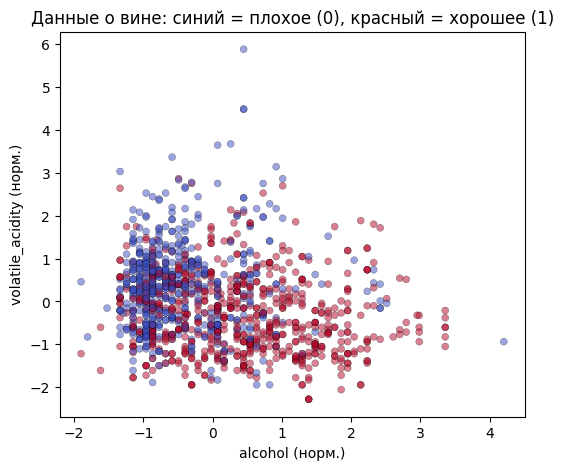

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1], c=y_tr,
            cmap='coolwarm', alpha=0.5, edgecolors='k', linewidths=0.3, s=25)
plt.xlabel('alcohol (норм.)')
plt.ylabel('volatile_acidity (норм.)')
plt.title('Данные о вине: синий = плохое (0), красный = хорошее (1)')
plt.show()

---
## Часть 2. Квадратичный дискриминантный анализ (QDA)

QDA строит **отдельную** ковариационную матрицу $\mathbf{\Sigma}_c$ для каждого класса — граница решений является **квадратичной**.

In [10]:
class QDA:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = dict()
    self.classes = None

  def fit(self, X, y):
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)
      self.covariances[c] = np.cov(X_c, rowvar=False)

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances[c])
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x - self.means[c]
        log_likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + log_likelihood
        log_posteriors.append(log_posterior)

      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      cov = self.covariances[i]

      rv = multivariate_normal(mean, cov)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('QDA Decision Boundary')
    plt.xlabel('alcohol (норм.)')
    plt.ylabel('volatile_acidity (норм.)')
    plt.show()

Точность (2 признака): 0.74375


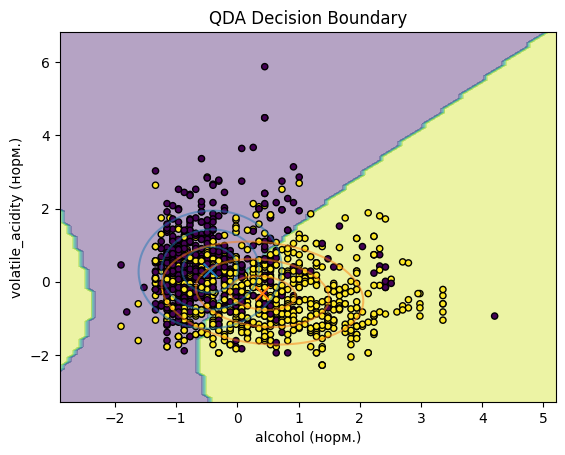

In [11]:
# QDA на 2 признаках — визуализация
qda_2d = QDA()
qda_2d.fit(X_tr_2d, y_tr)
print('Точность (2 признака):', accuracy_score(y_te, qda_2d.predict(X_te_2d)))
qda_2d.decision_boundary(X_tr_2d, y_tr)

In [12]:
# QDA на всех 11 признаках
qda_full = QDA()
qda_full.fit(X_tr_full, y_tr)
print('Точность (все признаки):', accuracy_score(y_te, qda_full.predict(X_te_full)))

Точность (все признаки): 0.709375


На графике видна характерная квадратичная граница — она изогнута и делит пространство по диагонали с небольшим «карманом» в левой нижней части.
  Жёлтая область соответствует классу «хорошее вино» (высокий alcohol, низкий volatile_acidity), фиолетовая — «плохое». Контурные эллипсы показывают
  форму распределений каждого класса: у класса «плохое» (тёмные точки) эллипс более вытянут по вертикали — дисперсия volatile_acidity выше, у класса
  «хорошее» — эллипс более компактный и смещён вправо. Именно разница в форме ковариационных матриксов и порождает квадратичную, а не прямую границу.

  Точность на 2 признаках — 0.744, на всех 11 — 0.709. Результат на полном наборе признаков оказался ниже, что на первый взгляд неожиданно. Причина —
   QDA оценивает отдельную ковариационную матрицу для каждого класса, и при большом числе признаков (11) и относительно небольшой выборке эти оценки
  становятся нестабильными. Два наиболее информативных признака (alcohol, volatile_acidity) дают модели достаточно сигнала, тогда как остальные 9
  добавляют шум.

---
## Часть 3. Линейный дискриминантный анализ (LDA)

LDA допускает, что ковариационная матрица **одинакова для всех классов** $\mathbf{\Sigma}_c = \mathbf{\Sigma}$ — это упрощение делает границу решений **линейной**. Кроме того, LDA может использоваться для **понижения размерности** через критерий Фишера.

In [13]:
class LDA:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = None
    self.classes = None

  def fit(self, X, y):
    self.covariances = np.cov(X, rowvar=False)
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances)
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x - self.means[c]
        log_likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + log_likelihood
        log_posteriors.append(log_posterior)
      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def fit_transform(self, X, y, n_components=2):
    self.classes = np.unique(y)
    n_features = X.shape[1]
    overall_mean = np.mean(X, axis=0)
    SW = np.zeros((n_features, n_features))
    SB = np.zeros((n_features, n_features))

    for c in self.classes:
      X_c = X[y == c]
      mean_c = np.mean(X_c, axis=0)
      SW += (X_c - mean_c).T.dot((X_c - mean_c))
      n_c = X_c.shape[0]
      mean_diff = (mean_c - overall_mean).reshape(n_features, 1)
      SB += n_c * (mean_diff).dot(mean_diff.T)

    A = np.linalg.inv(SW).dot(SB)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors.T)

    idxs = np.argsort(np.abs(eigenvalues))[::-1]
    eigenvalues = np.abs(eigenvalues[idxs])
    eigenvectors = eigenvectors[idxs]
    W = eigenvectors[:n_components]

    return np.dot(X, W.T)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      rv = multivariate_normal(mean, self.covariances)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('LDA Decision Boundary')
    plt.xlabel('alcohol (норм.)')
    plt.ylabel('volatile_acidity (норм.)')
    plt.show()

Точность (2 признака): 0.759375


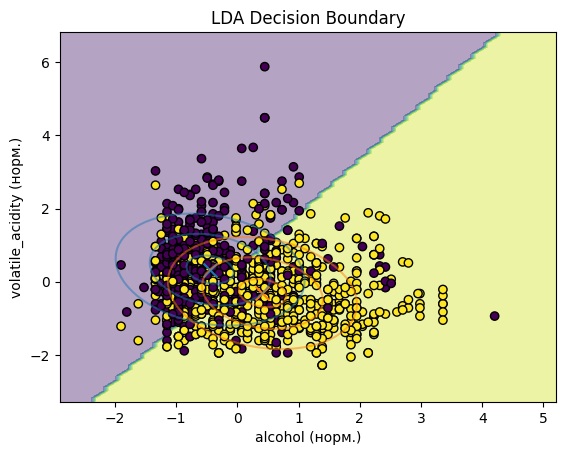

In [14]:
# LDA на 2 признаках — визуализация
lda_2d = LDA()
lda_2d.fit(X_tr_2d, y_tr)
print('Точность (2 признака):', accuracy_score(y_te, lda_2d.predict(X_te_2d)))
lda_2d.decision_boundary(X_tr_2d, y_tr)

In [15]:
# LDA на всех 11 признаках
lda_full = LDA()
lda_full.fit(X_tr_full, y_tr)
print('Точность (все признаки):', accuracy_score(y_te, lda_full.predict(X_te_full)))

Точность (все признаки): 0.74375


Граница решений LDA — строго прямая линия, проходящая по диагонали. Это принципиальное отличие от QDA: поскольку LDA использует одну общую
  ковариационную матрицу для обоих классов, форма распределений считается одинаковой — отсюда линейная, а не изогнутая граница. Контурные эллипсы
  обоих классов имеют одинаковую ориентацию, но смещены относительно друг друга: «плохое вино» (тёмные точки) сосредоточено в области низкого alcohol
   и высокого volatile_acidity, «хорошее» (жёлтые) — в области высокого alcohol и низкого volatile_acidity.

  Точность на 2 признаках — 0.759, на всех 11 — 0.744. В отличие от QDA, добавление признаков здесь также незначительно снижает результат, но разрыв
  меньше: общая ковариационная матрица оценивается устойчивее при большем числе признаков, так как данные всех классов объединяются. Тем не менее два
   выбранных признака оказываются наиболее информативными и дают лучший результат.

  По сравнению с QDA (0.744 на 2 признаках) LDA показывает точность выше (0.759) — линейное допущение здесь оправдано: данные о вине не требуют
  сложной квадратичной границы на этих двух признаках.



### LDA для понижения размерности

При бинарной классификации (2 класса) LDA может найти не более $C - 1 = 1$ линейного дискриминанта. Проецируем 11-мерные данные на одну ось и смотрим, насколько хорошо классы разделяются.

Исходная размерность: (1599, 11), после LDA: (1599, 1)


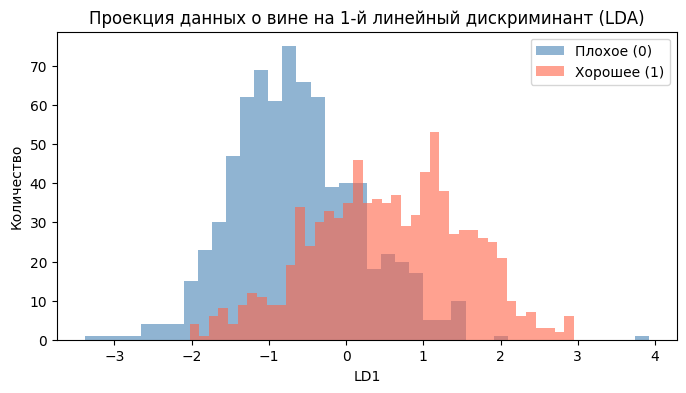

In [16]:
lda_dr = LDA()
X_lda = lda_dr.fit_transform(X_full, y_wine, n_components=1)
print(f'Исходная размерность: {X_full.shape}, после LDA: {X_lda.shape}')

plt.figure(figsize=(8, 4))
for label, color, name in [(0, 'steelblue', 'Плохое (0)'), (1, 'tomato', 'Хорошее (1)')]:
    plt.hist(X_lda[y_wine == label, 0], bins=40, alpha=0.6, color=color, label=name)
plt.xlabel('LD1')
plt.ylabel('Количество')
plt.title('Проекция данных о вине на 1-й линейный дискриминант (LDA)')
plt.legend()
plt.show()

LDA сжал 11 признаков в одно число — проекцию на ось LD1, которая максимизирует расстояние между центрами классов относительно их внутреннего
  разброса (критерий Фишера).

  На гистограмме видно, что классы частично разделились: «плохое вино» (синий) сосредоточено преимущественно в отрицательной области LD1 (примерно от
   −3 до 0), «хорошее вино» (красный) — в положительной (от 0 до 4). Центры распределений заметно смещены относительно друг друга, что говорит о том,
   что LD1 действительно несёт дискриминативную информацию.

  При этом классы значительно перекрываются в районе нуля — полностью разделить их одной осью невозможно, что согласуется с результатами
  классификации (точность ~74%). Это ожидаемо: при бинарной классификации LDA находит ровно одну ось (C − 1 = 1), и если данные сложно разделимы в
  исходном пространстве, одна проекция не устранит перекрытие полностью.

---
## Часть 4. Gaussian Naïve Bayes

Gaussian NB добавляет ещё одно допущение: признаки **независимы** внутри каждого класса. Ковариационная матрица становится **диагональной** (только дисперсии на главной диагонали, ковариации обнуляются).

In [17]:
class GaussianNaiveBayes:
  def __init__(self):
    self.priors = dict()
    self.means = dict()
    self.covariances = dict()
    self.classes = None

  def fit(self, X, y):
    self.classes = np.unique(y)

    for c in self.classes:
      X_c = X[y == c]
      self.priors[c] = X_c.shape[0] / X.shape[0]
      self.means[c] = np.mean(X_c, axis=0)
      self.covariances[c] = np.diag(np.diag(np.cov(X_c, rowvar=False)))

  def predict(self, X):
    predictions = list()
    for x in X:
      log_posteriors = list()
      for c in self.classes:
        log_priors = np.log(self.priors[c])
        inv_cov = np.linalg.inv(self.covariances[c])
        inv_cov_det = np.linalg.det(inv_cov)
        diff = x - self.means[c]
        likelihood = 0.5 * np.log(inv_cov_det) - 0.5 * diff.T @ inv_cov @ diff
        log_posterior = log_priors + likelihood
        log_posteriors.append(log_posterior)
      prediction = self.classes[np.argmax(log_posteriors)]
      predictions.append(prediction)
    return np.array(predictions)

  def decision_boundary(self, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                          np.arange(y_min, y_max, 0.1))

    Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    for i, _ in enumerate(self.classes):
      mean = self.means[i]
      cov = np.diag(self.covariances[i])

      rv = multivariate_normal(mean, cov)
      x_grid, y_grid = np.mgrid[x_min:x_max:0.1, y_min:y_max:0.1]
      points = np.dstack((x_grid, y_grid))
      pdf_values = rv.pdf(points)

      plt.contour(x_grid, y_grid, pdf_values, levels=3, colors=f'C{i}', alpha=0.5)
      plt.scatter(mean[0], mean[1], marker='x', color=f'C{i}', s=100)

    plt.title('Gaussian Naive Bayes Decision Boundary')
    plt.xlabel('alcohol (норм.)')
    plt.ylabel('volatile_acidity (норм.)')
    plt.show()

Точность (2 признака): 0.75


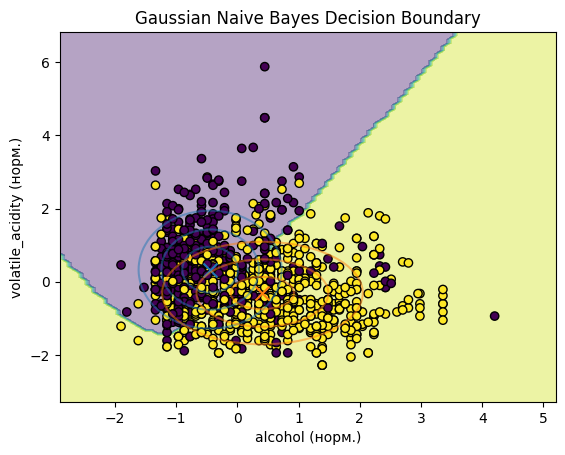

In [18]:
# GNB на 2 признаках — визуализация
gnb_2d = GaussianNaiveBayes()
gnb_2d.fit(X_tr_2d, y_tr)
print('Точность (2 признака):', accuracy_score(y_te, gnb_2d.predict(X_te_2d)))
gnb_2d.decision_boundary(X_tr_2d, y_tr)

In [19]:
# GNB на всех 11 признаках
gnb_full = GaussianNaiveBayes()
gnb_full.fit(X_tr_full, y_tr)
print('Точность (все признаки):', accuracy_score(y_te, gnb_full.predict(X_te_full)))

Точность (все признаки): 0.721875


Граница Gaussian NB — квадратичная кривая, как и у QDA, но её форма отличается: она более плавная и симметричная. Это следствие диагональной
  ковариационной матрицы — модель предполагает, что признаки независимы, поэтому контурные эллипсы каждого класса выровнены строго по осям координат
  (без наклона). Сравнивая с QDA, где эллипсы могут быть повёрнуты произвольно, видно, что здесь они более «круглые» и не учитывают корреляцию между
  alcohol и volatile_acidity.

  Точность на 2 признаках — 0.750, на всех 11 — 0.722. Картина схожа с QDA: добавление признаков незначительно снижает результат. Однако на 2
  признаках Gaussian NB показывает чуть лучший результат, чем QDA (0.750 против 0.744) — несмотря на более сильное допущение о независимости
  признаков. Это говорит о том, что корреляция между alcohol и volatile_acidity невелика и её учёт не даёт QDA существенного преимущества на этих
  двух признаках.

---
## Итоги

Сравниваем QDA, LDA и Gaussian NB на данных о вине — на 2 признаках и на всех 11.

                  Модель  Точность
        LDA (2 признака)  0.759375
Gaussian NB (2 признака)  0.750000
      LDA (все признаки)  0.743750
        QDA (2 признака)  0.743750
       Gaussian NB (все)  0.721875
      QDA (все признаки)  0.709375


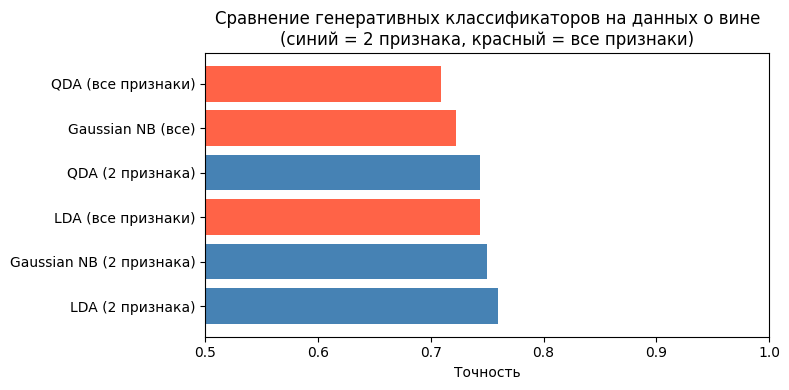

In [22]:
results = {
    'QDA (2 признака)':         accuracy_score(y_te, qda_2d.predict(X_te_2d)),
    'QDA (все признаки)':       accuracy_score(y_te, qda_full.predict(X_te_full)),
    'LDA (2 признака)':         accuracy_score(y_te, lda_2d.predict(X_te_2d)),
    'LDA (все признаки)':       accuracy_score(y_te, lda_full.predict(X_te_full)),
    'Gaussian NB (2 признака)': accuracy_score(y_te, gnb_2d.predict(X_te_2d)),
    'Gaussian NB (все)':        accuracy_score(y_te, gnb_full.predict(X_te_full)),
}

res_df = pd.DataFrame(results.items(), columns=['Модель', 'Точность'])
res_df = res_df.sort_values('Точность', ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))

plt.figure(figsize=(8, 4))
colors_bar = ['steelblue' if '2 признака' in m else 'tomato' for m in res_df['Модель']]
plt.barh(res_df['Модель'], res_df['Точность'], color=colors_bar)
plt.xlim(0.5, 1.0)
plt.xlabel('Точность')
plt.title('Сравнение генеративных классификаторов на данных о вине\n(синий = 2 признака, красный = все признаки)')
plt.tight_layout()
plt.show()

На графике прослеживаются два чётких паттерна.

  Синие столбцы (2 признака) стабильно превосходят красные (все признаки) для всех трёх алгоритмов. Это контринтуитивный результат: больше признаков
  — хуже точность. Причина в том, что генеративные классификаторы оценивают параметры распределений (средние и ковариации) из данных, и при
  увеличении числа признаков эти оценки становятся менее точными. Два отобранных признака (alcohol, volatile_acidity) оказались наиболее
  информативными и не «разбавлены» шумом от остальных девяти.

  Лидер — LDA на 2 признаках (0.759). Это неожиданно: LDA делает самое сильное допущение из трёх (одна общая ковариация для всех классов), но именно
  оно оказывается наиболее оправданным на этих данных — классы вина в пространстве alcohol/volatile_acidity действительно имеют схожую форму
  распределения, и линейная граница справляется лучше, чем квадратичная.

  QDA на всех признаках — аутсайдер (0.709). Оценка 11×11 ковариационной матрицы отдельно для каждого класса требует большого объёма данных, которого
   здесь недостаточно.

  Общий вывод: для данных о вине генеративные классификаторы показывают умеренную точность (~72–76%). Их главное преимущество перед дискриминативными
   моделями — интерпретируемость: модель явно моделирует распределение каждого класса, что позволяет не только классифицировать, но и понимать
  структуру данных.